In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 200
Number of columns: 5


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [6]:
print(df.dtypes)

Unnamed: 0      int64
TV            float64
Radio         float64
Newspaper     float64
Sales         float64
dtype: object


In [8]:
print(df.isnull().sum())

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


In [9]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [10]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [11]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (200, 5)


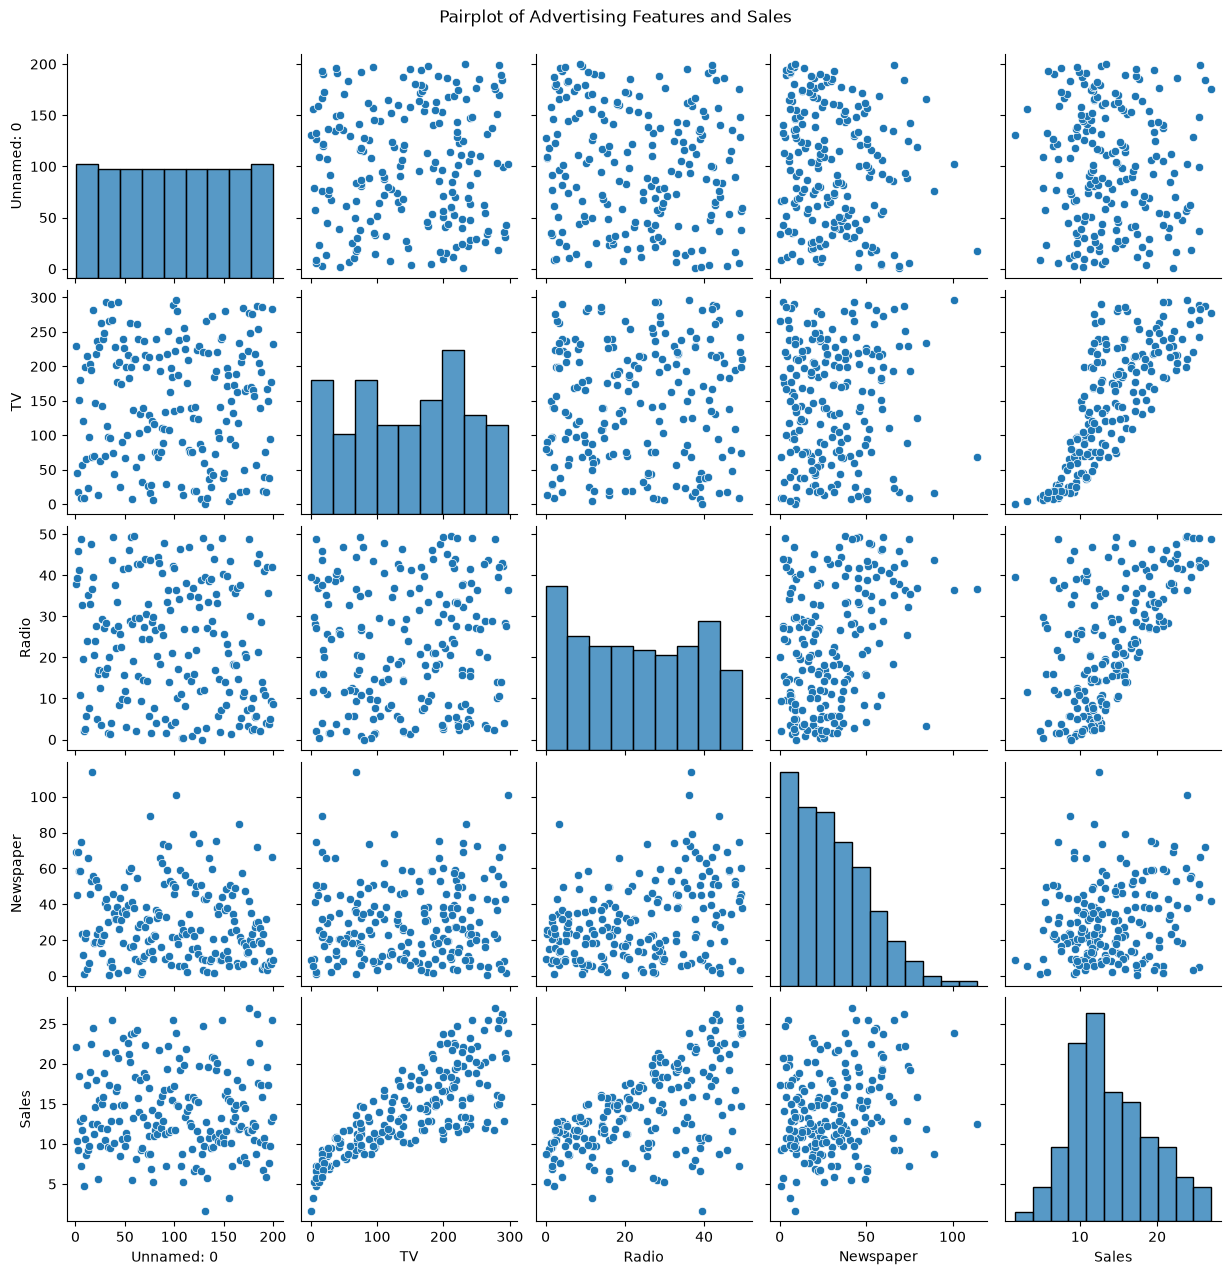

In [12]:
sns.pairplot(df)
plt.suptitle("Pairplot of Advertising Features and Sales", y=1.02)
plt.show()

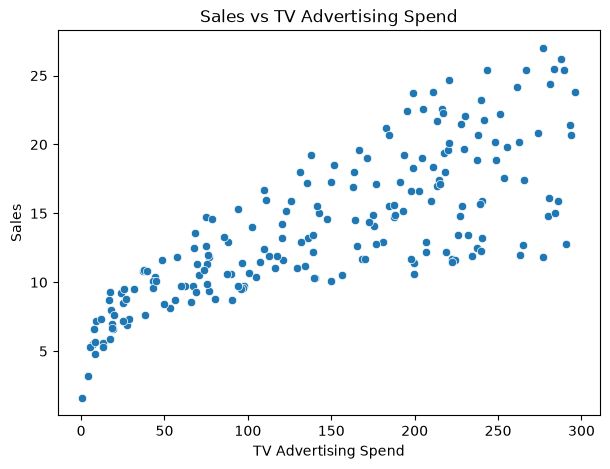

In [13]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x="TV", y="Sales", data=df)
plt.title("Sales vs TV Advertising Spend")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")
plt.show()

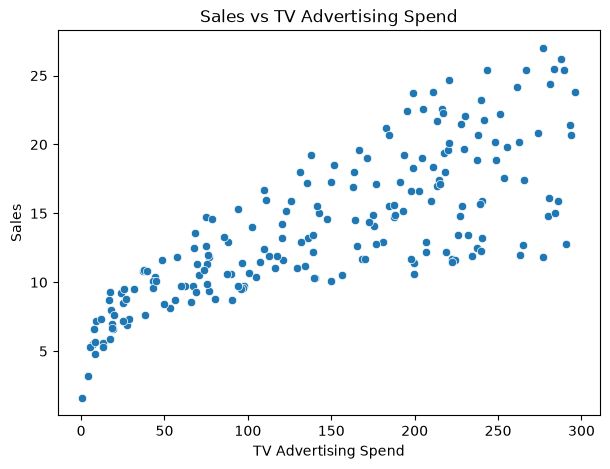

In [14]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x="TV", y="Sales", data=df)
plt.title("Sales vs TV Advertising Spend")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")
plt.show()

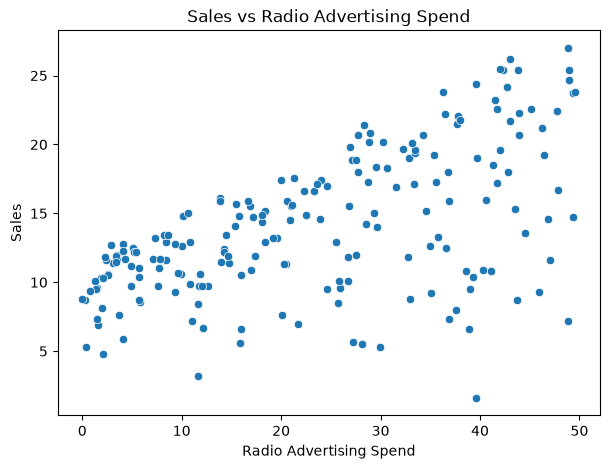

In [15]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x="Radio", y="Sales", data=df)
plt.title("Sales vs Radio Advertising Spend")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")
plt.show()

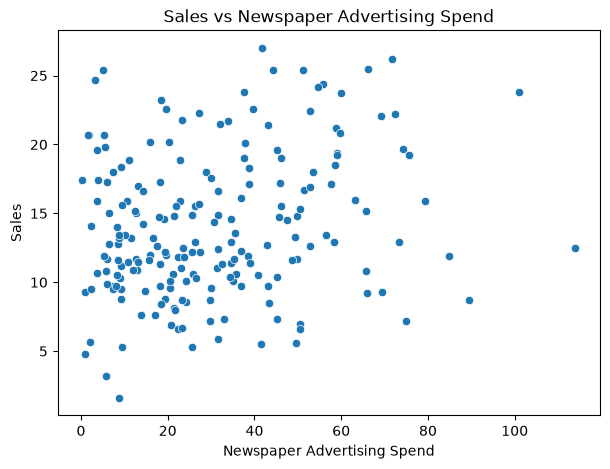

In [16]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x="Newspaper", y="Sales", data=df)
plt.title("Sales vs Newspaper Advertising Spend")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")
plt.show()

In [17]:
correlation_matrix = df.corr()

print(correlation_matrix)

            Unnamed: 0        TV     Radio  Newspaper     Sales
Unnamed: 0    1.000000  0.017715 -0.110680  -0.154944 -0.051616
TV            0.017715  1.000000  0.054809   0.056648  0.782224
Radio        -0.110680  0.054809  1.000000   0.354104  0.576223
Newspaper    -0.154944  0.056648  0.354104   1.000000  0.228299
Sales        -0.051616  0.782224  0.576223   0.228299  1.000000


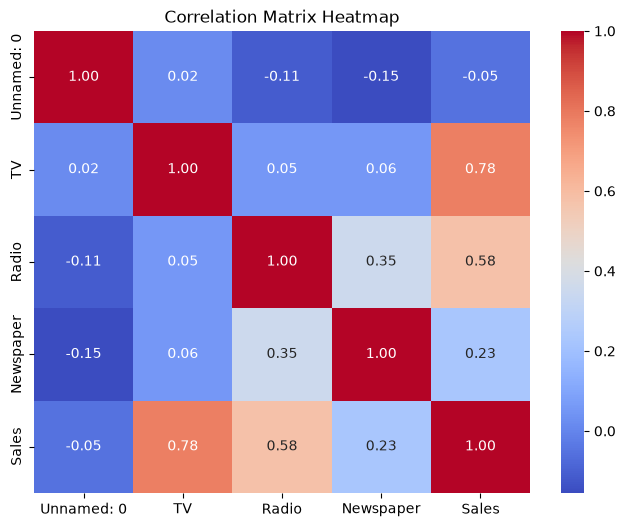

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

In [19]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [21]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.04,0.19,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['TV','Radio','Newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.979
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [22]:
y_pred_linear = linear_model.predict(X_test)

print(y_pred_linear[:10])

[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [23]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R² Score:", r2_linear)

Linear Regression Results
-------------------------
MAE : 1.4607567168117606
RMSE: 1.7815996615334506
R² Score: 0.899438024100912


In [24]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients

,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


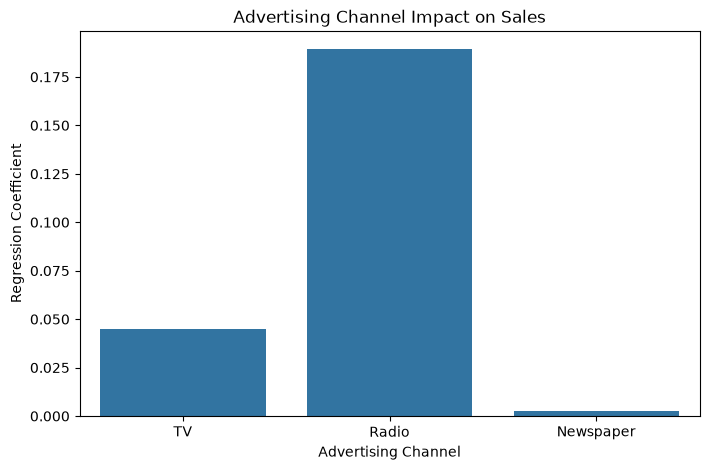

In [25]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Feature", y="Coefficient", data=coefficients)
plt.title("Advertising Channel Impact on Sales")
plt.xlabel("Advertising Channel")
plt.ylabel("Regression Coefficient")
plt.show()

In [26]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [27]:
y_pred_rf = rf_model.predict(X_test)

print(y_pred_rf[:10])

[17.698 21.804 20.619  6.793 22.927 13.379 22.376  9.688 11.826 15.54 ]


In [28]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Results
---------------------
MAE : 0.6203249999999988
RMSE: 0.7687170968568338
R² Score: 0.9812782416450916


In [29]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_linear, mae_rf],
    "RMSE": [rmse_linear, rmse_rf],
    "R² Score": [r2_linear, r2_rf]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.620325,0.768717,0.981278


In [30]:
best_model_name = results.loc[results["R² Score"].idxmax(), "Model"]

print("Best Performing Model:", best_model_name)

Best Performing Model: Random Forest


In [31]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,TV,0.624810
1,Radio,0.362214
2,Newspaper,0.012976


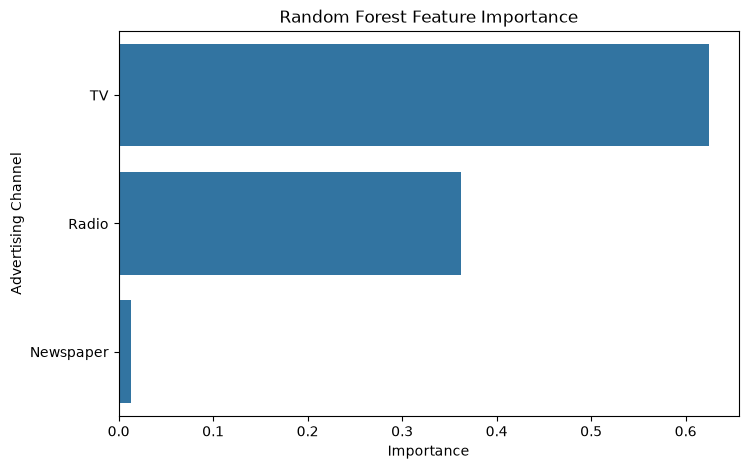

In [32]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")
plt.show()

In [33]:
if best_model_name == "Linear Regression":
    best_predictions = y_pred_linear
else:
    best_predictions = y_pred_rf

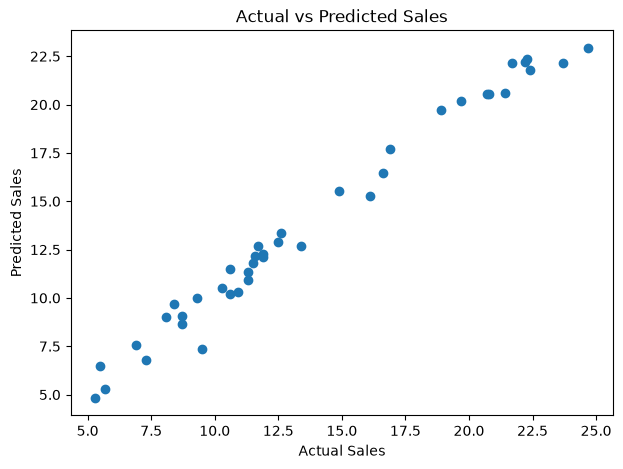

In [34]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, best_predictions)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [35]:
residuals = y_test - best_predictions

print(residuals.head())

95    -0.798
15     0.596
30     0.781
158    0.507
128    1.773
Name: Sales, dtype: float64


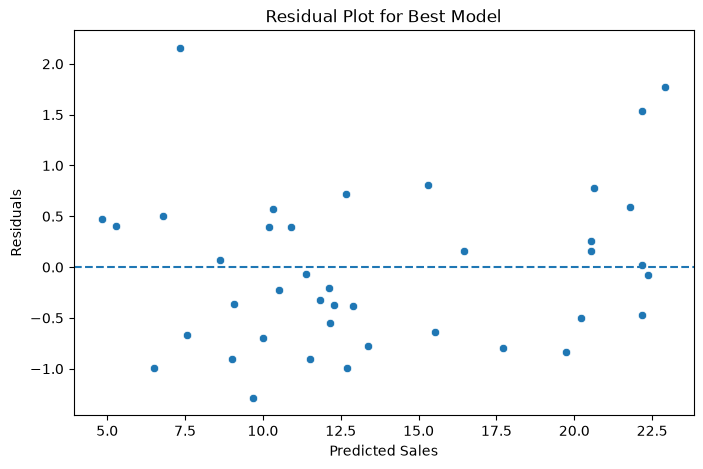

In [36]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=best_predictions, y=residuals)

plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot for Best Model")

plt.show()

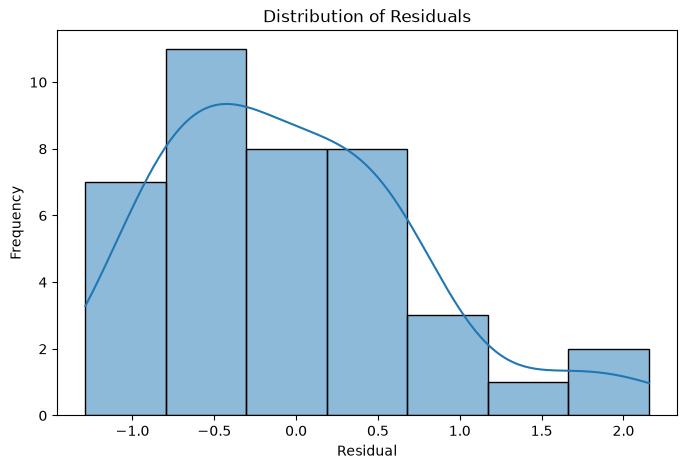

In [37]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

In [38]:
print("FINAL MODEL PERFORMANCE")
print("=======================")
print("Best Model:", best_model_name)

if best_model_name == "Linear Regression":
    print("MAE :", mae_linear)
    print("RMSE:", rmse_linear)
    print("R² Score:", r2_linear)
else:
    print("MAE :", mae_rf)
    print("RMSE:", rmse_rf)
    print("R² Score:", r2_rf)

FINAL MODEL PERFORMANCE
Best Model: Random Forest
MAE : 0.6203249999999988
RMSE: 0.7687170968568338
R² Score: 0.9812782416450916


In [39]:
most_important_channel = feature_importance.iloc[0]["Feature"]

print("Most influential advertising channel:", most_important_channel)

Most influential advertising channel: TV


In [40]:
new_advertising_data = pd.DataFrame({
    "TV": [150],
    "Radio": [30],
    "Newspaper": [20]
})

predicted_sales = rf_model.predict(new_advertising_data)

print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 16.679999999999986


In [41]:
print("Sales Prediction Project Completed")
print("-----------------------------------")
print("Dataset shape:", df.shape)
print("Best model:", best_model_name)
print("Most influential advertising channel:", most_important_channel)

Sales Prediction Project Completed
-----------------------------------
Dataset shape: (200, 5)
Best model: Random Forest
Most influential advertising channel: TV


### Conclusion

The Sales Prediction project successfully built a regression-based Machine Learning model to predict product sales using advertising expenditure on **TV, Radio, and Newspaper**. The dataset was explored through descriptive statistics, pairplots, scatter plots, and a correlation heatmap to understand the relationship between advertising channels and sales.

Two regression models, **Linear Regression** and **Random Forest Regressor**, were trained and evaluated using **MAE, RMSE, and R² Score**. The models were compared to identify the better-performing approach. A residual plot was also used to examine whether the prediction errors were randomly distributed.

The feature analysis helped identify the **advertising channel with the highest impact on sales**. Overall, the project demonstrates how Machine Learning can use historical advertising data to estimate future sales and support better advertising and marketing decisions.